## LINK VIDEO GOOGLE DRIVE

https://drive.google.com/file/d/1Ue3HkocH_8OoSXRRFa4QJ4mGutQ1B690/view?usp=sharing

# Soal no 3: Image Generation dengan Conditional GAN (CGAN)
Dataset: Car dan Plane

Arsitektur yang digunakan adalah Conditional GAN (CGAN), bukan vanilla GAN, karena diagram di soal menunjukkan adanya Embedding(labels) pada Generator dan Discriminator, yang merupakan ciri khas CGAN. Dengan kondisi label, generator dapat menghasilkan gambar dari kelas tertentu secara terkontrol.

## 3a. Cara Kerja Arsitektur GAN/CGAN

### Penjelasan Arsitektur GAN

Generative Adversarial Network (GAN) terdiri dari dua jaringan neural yang saling berkompetisi secara adversarial:

#### 1. Generator (G)
- Menerima input berupa random noise (vektor dari distribusi Gaussian/Uniform)
- Bertugas menghasilkan gambar palsu (fake images) yang semirip mungkin dengan data asli
- Dilatih agar bisa "menipu" Discriminator

#### 2. Discriminator (D)
- Menerima input gambar (asli dari training set ATAU palsu dari Generator)
- Bertugas membedakan gambar asli (Real) vs palsu (Fake)
- Output berupa probabilitas: mendekati 1 = asli, mendekati 0 = palsu

#### Proses Training (Minimax Game)
Training GAN merupakan permainan zero-sum dua pemain:
- Discriminator dilatih untuk memaksimalkan kemampuan membedakan real vs fake
- Generator dilatih untuk meminimalkan kemampuan Discriminator (memaksimalkan kesalahan D)
- Fungsi loss GAN: min_G max_D [ E[log D(x)] + E[log(1 - D(G(z)))] ]

#### Mengapa CGAN? (Conditional GAN)
Pada diagram soal, terdapat Embedding(labels) di Generator dan Discriminator. Ini adalah CGAN, di mana:
- Generator menerima noise + label -> menghasilkan gambar dari kelas spesifik
- Discriminator menerima gambar + label → menentukan apakah gambar real/fake untuk label tersebut
- Keunggulan: generasi gambar dapat dikontrol berdasarkan kelas yang diinginkan

#### Proses Konvergensi
Idealnya, training berakhir saat Generator menghasilkan gambar yang tidak bisa dibedakan dari gambar asli oleh Discriminator (D(G(z)) ≈ 0.5 untuk semua input).

## 3b. Arsitektur Baseline CGAN

Sesuai diagram arsitektur di soal:

**Generator:**
- Input: Noise + Embedding(labels)
- Linear(noise + n_labels → 128) → Linear(128 → 256) → Linear(256 → 512) → Linear(512 → 1024) → Linear(1024 → img_size²)

**Discriminator:**
- Input: Image + Embedding(labels)
- Linear(n_labels + img_size² → 512) → Linear(512 → 1024) → Linear(1024 → 1024) → Linear(1024 → 512) → Linear(512 → 1)

Evaluasi dengan **Fréchet Inception Distance (FID)**.

In [ ]:
# IMPORT LIBRARIES
import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import torch.nn.functional as F

from scipy import linalg
from torchvision.models import inception_v3

print('Libraries imported successfully!')
print(f'PyTorch version: {torch.__version__}')
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

torch.manual_seed(42)
np.random.seed(42)

Libraries imported successfully!
PyTorch version: 2.11.0+cpu
Device: cpu


mengimpor semua library yang dibutuhkan. os dan numpy digunakan untuk operasi file dan manipulasi array numerik. matplotlib dan PIL untuk visualisasi dan pembacaan gambar. sklearn digunakan khusus untuk fungsi train_test_split. Dari PyTorch, diimpor modul inti (torch, nn, optim), utilitas data (DataLoader, TensorDataset), dan fungsi aktivasi (F). scipy.linalg diperlukan untuk menghitung akar matriks kovarians pada metrik FID, dan inception_v3 dari torchvision digunakan sebagai feature extractor. Selain itu, ditetapkan seed (torch.manual_seed(42) dan np.random.seed(42)) agar setiap kali dijalankan ulang, hasilnya akan konsisten.

Output: Konfirmasi teks Libraries imported successfully!, versi PyTorch (2.11.0+cpu), dan device yang digunakan (cpu)

In [ ]:
import zipfile

with zipfile.ZipFile('/content/deepLearningDataset.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/')

lalu, mengekstrak file deepLearningDataset.zip ke direktori /content/ menggunakan modul zipfile. Setelah ekstraksi, lalu memverifikasi struktur folder hasil ekstraksi.

In [ ]:
!find /content -type d | grep overhead

/content/__MACOSX/deepLearningDataset/overhead
/content/__MACOSX/deepLearningDataset/overhead/testing
/content/__MACOSX/deepLearningDataset/overhead/testing/plane
/content/__MACOSX/deepLearningDataset/overhead/testing/parking_lot
/content/__MACOSX/deepLearningDataset/overhead/testing/ship
/content/__MACOSX/deepLearningDataset/overhead/testing/storage_tank
/content/__MACOSX/deepLearningDataset/overhead/testing/harbor
/content/__MACOSX/deepLearningDataset/overhead/testing/oil_gas_field
/content/__MACOSX/deepLearningDataset/overhead/testing/helicopter
/content/__MACOSX/deepLearningDataset/overhead/testing/car
/content/__MACOSX/deepLearningDataset/overhead/testing/stadium
/content/__MACOSX/deepLearningDataset/overhead/testing/runway_mark
/content/__MACOSX/deepLearningDataset/overhead/training
/content/__MACOSX/deepLearningDataset/overhead/training/plane
/content/__MACOSX/deepLearningDataset/overhead/training/parking_lot
/content/__MACOSX/deepLearningDataset/overhead/training/ship
/content/

Outputnya adalah daftar direktori yang menunjukkan dataset Overhead-MNIST terorganisir dalam dua split utama (training dan testing), masing-masing memiliki subfolder per kelas (car, plane, ship, dll.)

In [ ]:
# LOAD DAN PERSIAPKAN DATA
def load_images_from_folder(folder_path, label):
    images, labels = [], []
    for filename in sorted(os.listdir(folder_path)):
        if filename.lower().endswith(('.jpg', '.png')):
            img = Image.open(os.path.join(folder_path, filename)).convert('L')
            images.append(np.array(img, dtype=np.float32))
            labels.append(label)
    return np.array(images), np.array(labels)

BASE_PATH = '/content/deepLearningDataset/overhead'

X_car_tr, y_car_tr     = load_images_from_folder(os.path.join(BASE_PATH, 'training', 'car'), 0)
X_plane_tr, y_plane_tr = load_images_from_folder(os.path.join(BASE_PATH, 'training', 'plane'), 1)
X_car_te, y_car_te     = load_images_from_folder(os.path.join(BASE_PATH, 'testing', 'car'), 0)
X_plane_te, y_plane_te = load_images_from_folder(os.path.join(BASE_PATH, 'testing', 'plane'), 1)

X_all = np.concatenate([X_car_tr, X_plane_tr, X_car_te, X_plane_te], axis=0)
y_all = np.concatenate([y_car_tr, y_plane_tr, y_car_te, y_plane_te], axis=0)

# Normalisasi ke [-1, 1]
X_norm = (X_all / 255.0) * 2 - 1  #range [-1, 1]
X_flat = X_norm.reshape(-1, 784)

# Split: 80% train, 10% val, 10% test
X_train, X_temp, y_train, y_temp = train_test_split(X_flat, y_all, test_size=0.20, random_state=42, stratify=y_all)
X_val, X_test, y_val, y_test     = train_test_split(X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp)

print(f'Total: {len(X_all)} | Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}')
print(f'Kelas: Car=0, Plane=1 | n_labels=2')

IMG_SIZE  = 28
N_LABELS  = 2
NOISE_DIM = 100

Total: 2000 | Train: 1600 | Val: 200 | Test: 200
Kelas: Car=0, Plane=1 | n_labels=2


Fungsi load_images_from_folder membaca semua file gambar berekstensi .jpg atau .png dari suatu folder, mengonversinya ke grayscale dengan .convert('L'), lalu menyimpan array-nya beserta label numerik yang diberikan. Semua gambar dari keempat split (car train, plane train, car test, plane test) digabungkan menjadi satu array X_all berukuran (2000, 28, 28).
Selanjutnya dilakukan normalisasi ke rentang [-1, 1] dengan rumus (X / 255.0) * 2 - 1. Normalisasi ini wajib dilakukan karena Generator menggunakan aktivasi Tanh di layer output, yang menghasilkan nilai dalam rentang [-1, 1], sehingga skala data harus konsisten. Gambar kemudian di flatten menjadi vektor 1D berukuran 784 (28x28). Data kemudian dibagi menjadi train (80%), validation (10%), dan test (10%) secara bertahap menggunakan dua kali train_test_split.

Outputnya menunjukkan ringkasan jumlah data, yaitu total 2000, train 1600, Val 200, Test 200. Label Car = 0, Plane = 1.

In [ ]:
# DATALOADER
def make_loader(X, y, batch_size=64, shuffle=True):
    X_t = torch.FloatTensor(X)
    y_t = torch.LongTensor(y)
    return DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=shuffle)

BATCH_SIZE   = 64
train_loader = make_loader(X_train, y_train, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(X_val,   y_val,   BATCH_SIZE, shuffle=False)
test_loader  = make_loader(X_test,  y_test,  BATCH_SIZE, shuffle=False)
print('DataLoaders siap.')

DataLoaders siap.


Fungsi make_loader membungkus array NumPy ke dalam TensorDataset (menggabungkan tensor gambar dan label), lalu membuat DataLoader dengan batch size 64. shuffle=True pada train loader penting agar model tidak belajar urutan data. Tiga loader dibuat, yaitu train_loader, val_loader, dan test_loader.

In [ ]:
# ARSITEKTUR BASELINE CGAN

class BaselineGenerator(nn.Module):

    def __init__(self, noise_dim=100, n_labels=2, img_size=28):
        super().__init__()
        self.img_size  = img_size
        self.label_emb = nn.Embedding(n_labels, n_labels)

        self.net = nn.Sequential(
            nn.Linear(noise_dim + n_labels, 128),
            nn.LeakyReLU(0.2),
            nn.Linear(128, 256),
            nn.LeakyReLU(0.2),
            nn.Linear(256, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, img_size * img_size),
            nn.Tanh()  # Output [-1, 1]
        )

    def forward(self, noise, labels):
        label_input = self.label_emb(labels)        #(N, n_labels)
        x = torch.cat([noise, label_input], dim=1)  #(N, noise_dim + n_labels)
        return self.net(x)                          #(N, img_size^2)


class BaselineDiscriminator(nn.Module):
    def __init__(self, n_labels=2, img_size=28):
        super().__init__()
        self.label_emb = nn.Embedding(n_labels, n_labels)  # output: 2
        input_dim = img_size * img_size + n_labels         # 784 + 2 = 786
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),  # Linear(786, 512)
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 1024),
            nn.LeakyReLU(0.2),
            nn.Linear(1024, 512),
            nn.LeakyReLU(0.2),
            nn.Linear(512, 1),
            nn.Sigmoid()
        )

    def forward(self, imgs, labels):
        label_input = self.label_emb(labels)      # (N, 2)
        x = torch.cat([imgs, label_input], dim=1) # (N, 786)
        return self.net(x)

gen_b  = BaselineGenerator(NOISE_DIM, N_LABELS, IMG_SIZE).to(device)
disc_b = BaselineDiscriminator(N_LABELS, IMG_SIZE).to(device)

print(f'Discriminator input dim: {28*28 + N_LABELS}')  # harus 786
print('Model siap di-training!')

Discriminator input dim: 786
Model siap di-training!


Generator Baseline menerima dua input, yaitu noise vektor berukuran 100 dan label kelas. Label dilewatkan melalui nn.Embedding(2, 2) yang menghasilkan vektor berukuran 2 (sama dengan n_labels). Kedua input digabungkan (concat) menjadi vektor berukuran 102, lalu dilewatkan melalui 5 layer Linear yang semakin membesar, yaitu 128 -> 256 -> 512 -> 1024 -> 784, dengan aktivasi LeakyReLU(0.2) di setiap layer kecuali output. Layer terakhir menggunakan Tanh agar output berada di [-1, 1] sesuai normalisasi data.

Discriminator Baseline menggunakan nn.Embedding(2, 2), sehingga embedding label menghasilkan vektor berukuran 2 (sama dengan n_labels). Gambar (784-dim) dan embedding label (2-dim) di-concat menjadi vektor 786-dim, lalu dilewatkan melalui 5 layer Linear yang mengecil: 512 → 1024 → 1024 → 512 → 1, dengan aktivasi LeakyReLU(0.2) dan Sigmoid di output.

Output menunjukkan bahwa Discriminator input dim: 786 dan Model siap di-training!

In [ ]:
# FUNGSI HITUNG FID (Fréchet Inception Distance)

def calculate_fid(real_images, fake_images):
    """
    Hitung FID menggunakan aktivasi InceptionV3.
    real_images, fake_images: numpy array (N, 28, 28) dalam range [-1,1]

    Karena gambar 28x28 grayscale, kita resize ke 75x75 RGB dan
    ekstrak fitur dari InceptionV3 layer penultimate.
    """
    # Load InceptionV3 (pretrained)
    inception = inception_v3(pretrained=True, transform_input=False)
    inception.fc = nn.Identity()
    inception.eval().to(device)

    def preprocess(imgs):
        """Preprocess gambar untuk InceptionV3: resize 75x75, convert ke RGB."""
        imgs_resized = []
        for img in imgs:
            # Konversi dari [-1,1] ke [0,255]
            img_uint8 = ((img + 1) * 127.5).astype(np.uint8)
            # Resize ke 75x75 (minimum InceptionV3)
            pil_img = Image.fromarray(img_uint8).resize((75, 75), Image.BILINEAR)
            # Convert grayscale ke RGB
            pil_rgb = pil_img.convert('RGB')
            imgs_resized.append(np.array(pil_rgb, dtype=np.float32) / 255.0)
        imgs_np = np.stack(imgs_resized, axis=0)         # (N, 75, 75, 3)
        imgs_t  = torch.FloatTensor(imgs_np).permute(0, 3, 1, 2)  # (N, 3, 75, 75)
        return imgs_t

    def get_features(imgs_np):
        """Ekstrak fitur InceptionV3."""
        features = []
        imgs_t = preprocess(imgs_np)
        with torch.no_grad():
            for i in range(0, len(imgs_t), 32):
                batch = imgs_t[i:i+32].to(device)
                feat = inception(batch)
                features.append(feat.cpu().numpy())
        return np.concatenate(features, axis=0)

    # Ekstrak fitur
    real_feats = get_features(real_images)
    fake_feats = get_features(fake_images)

    # Hitung mean dan covariance
    mu_r, sigma_r = real_feats.mean(axis=0), np.cov(real_feats, rowvar=False)
    mu_f, sigma_f = fake_feats.mean(axis=0), np.cov(fake_feats, rowvar=False)

    # FID = ||mu_r - mu_f||^2 + Tr(sigma_r + sigma_f - 2*sqrt(sigma_r * sigma_f))
    diff = mu_r - mu_f
    covmean, _ = linalg.sqrtm(sigma_r @ sigma_f, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    fid = diff @ diff + np.trace(sigma_r + sigma_f - 2 * covmean)
    return float(fid)

print('Fungsi FID siap.')

Fungsi FID siap.


FID adalah metrik standar untuk mengukur kualitas gambar yang dihasilkan GAN. Semakin rendah nilai FID, semakin mirip distribusi gambar sintetik dengan distribusi gambar asli. Fungsi ini bekerja dengan tiga tahap, yaitu (1) memuat model InceptionV3 pretrained dan mengganti layer fully-connected terakhir dengan nn.Identity() agar output berupa feature vector (bukan prediksi kelas). (2) melakukan preprocessing pada gambar, mengonversi dari [-1,1] ke [0,255], meresize dari 28x28 ke 75x75 (ukuran minimum InceptionV3), dan mengonversi dari grayscale ke RGB. (3) mengekstrak fitur dari gambar asli dan palsu, menghitung mean (μ) dan matriks kovarians (Σ) masing-masing, lalu menghitung FID

In [ ]:
# TRAINING LOOP CGAN

def train_cgan(generator, discriminator, train_loader, epochs=100,
               lr_g=2e-4, lr_d=2e-4, noise_dim=100, n_labels=2):

    criterion  = nn.BCELoss()
    opt_G = optim.Adam(generator.parameters(),     lr=lr_g, betas=(0.5, 0.999))
    opt_D = optim.Adam(discriminator.parameters(), lr=lr_d, betas=(0.5, 0.999))

    g_losses, d_losses = [], []

    for epoch in range(1, epochs+1):
        g_loss_ep, d_loss_ep = 0, 0

        for real_imgs, real_labels in train_loader:
            real_imgs   = real_imgs.to(device)
            real_labels = real_labels.to(device)
            N = real_imgs.size(0)

            real_targets = torch.ones(N, 1, device=device)
            fake_targets = torch.zeros(N, 1, device=device)

            # TRAIN DISCRIMINATOR
            opt_D.zero_grad()

            # Loss pada gambar asli
            d_real = discriminator(real_imgs, real_labels)
            loss_d_real = criterion(d_real, real_targets)

            # Loss pada gambar palsu
            noise = torch.randn(N, noise_dim, device=device)
            fake_labels = torch.randint(0, n_labels, (N,), device=device)
            fake_imgs   = generator(noise, fake_labels).detach()
            d_fake = discriminator(fake_imgs, fake_labels)
            loss_d_fake = criterion(d_fake, fake_targets)

            loss_D = (loss_d_real + loss_d_fake) / 2
            loss_D.backward()
            opt_D.step()

            # TRAIN GENERATOR
            opt_G.zero_grad()

            noise = torch.randn(N, noise_dim, device=device)
            gen_labels = torch.randint(0, n_labels, (N,), device=device)
            gen_imgs   = generator(noise, gen_labels)
            d_gen      = discriminator(gen_imgs, gen_labels)
            # Generator ingin D mengira gambarnya asli
            loss_G = criterion(d_gen, real_targets)
            loss_G.backward()
            opt_G.step()

            g_loss_ep += loss_G.item()
            d_loss_ep += loss_D.item()

        g_loss_ep /= len(train_loader)
        d_loss_ep /= len(train_loader)
        g_losses.append(g_loss_ep)
        d_losses.append(d_loss_ep)

        if epoch % 20 == 0 or epoch == 1:
            print(f'Epoch [{epoch:3d}/{epochs}] | G Loss: {g_loss_ep:.4f} | D Loss: {d_loss_ep:.4f}')

    return g_losses, d_losses


print('Mulai training Baseline CGAN...')
g_losses_b, d_losses_b = train_cgan(
    gen_b, disc_b, train_loader,
    epochs=100, lr_g=2e-4, lr_d=2e-4,
    noise_dim=NOISE_DIM, n_labels=N_LABELS
)

Mulai training Baseline CGAN...
Epoch [  1/100] | G Loss: 1.0668 | D Loss: 0.3669
Epoch [ 20/100] | G Loss: 3.8329 | D Loss: 0.2829
Epoch [ 40/100] | G Loss: 4.5781 | D Loss: 0.1703
Epoch [ 60/100] | G Loss: 4.3145 | D Loss: 0.1623
Epoch [ 80/100] | G Loss: 3.7617 | D Loss: 0.2133
Epoch [100/100] | G Loss: 3.9472 | D Loss: 0.1772


Fungsi train_cgan mengimplementasikan training GAN standar. Optimizer yang digunakan adalah Adam dengan betas=(0.5, 0.999). Criterion menggunakan BCELoss (Binary Cross-Entropy Loss).
Setiap iterasi batch menjalankan dua langkah training secara bergantian.

Training Discriminator, yaitu pertama dihitung loss pada gambar asli (target = 1.0), lalu loss pada gambar palsu yang di generate (target = 0.0, dengan .detach() agar gradient tidak mengalir ke Generator). Total loss D adalah rata-rata keduanya.

Training Generator, yaitu noise baru di sample, Generator menghasilkan gambar palsu, dan loss Generator dihitung dengan target = 1.0 (Generator ingin Discriminator "tertipu" menganggap gambarnya asli).

Output menunjukkan bahwa Generator Loss meningkat drastis dari 1.07 di epoch 1 hingga berkisar antara 3.7-4.6 pada epoch-epoch berikutnya. Discriminator Loss justru terus menurun hingga berkisar antara 0.17-0.37

Discriminator Loss yang rendah (0.17–0.37) menunjukkan Discriminator cukup dominan dan mudah membedakan gambar asli vs palsu. Generator Loss yang tinggi (3.7-4.6) menunjukkan Generator kesulitan menipu Discriminator.

Kondisi ideal GAN adalah ketika D Loss ≈ 0.693 (ln 2), yang berarti Discriminator tidak lebih baik dari tebakan acak. Gap yang besar ini mengindikasikan training tidak seimbang dan discriminator terlalu kuat dibanding generator

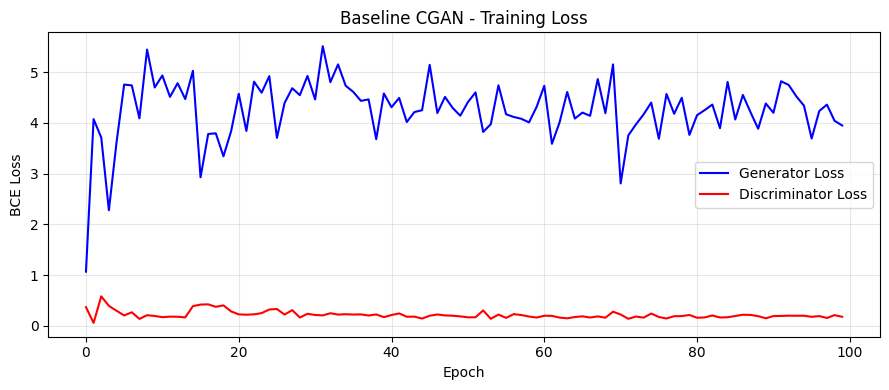

In [ ]:
# PLOT TRAINING LOSS BASELINE CGAN
plt.figure(figsize=(9, 4))
plt.plot(g_losses_b, label='Generator Loss', color='blue')
plt.plot(d_losses_b, label='Discriminator Loss', color='red')
plt.title('Baseline CGAN - Training Loss')
plt.xlabel('Epoch')
plt.ylabel('BCE Loss')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('baseline_cgan_loss.png', dpi=100)
plt.show()

code ini memvisualisasikan kurva Generator Loss (biru) dan Discriminator Loss (merah) selama 100 epoch.

Discriminator Loss langsung jatuh mendekati 0 sejak epoch awal dan tetap sangat rendah (di bawah 0.5) sepanjang training. Generator Loss sebaliknya melonjak tinggi hingga mencapai 5 dan terus berfluktuasi di kisaran 3-5 tanpa tren penurunan. Pola ini jauh lebih parah dibanding baseline GAN yang normal, gap sebesar ini menunjukkan bahwa Discriminator menang dan Generator tidak berhasil belajar sama sekali

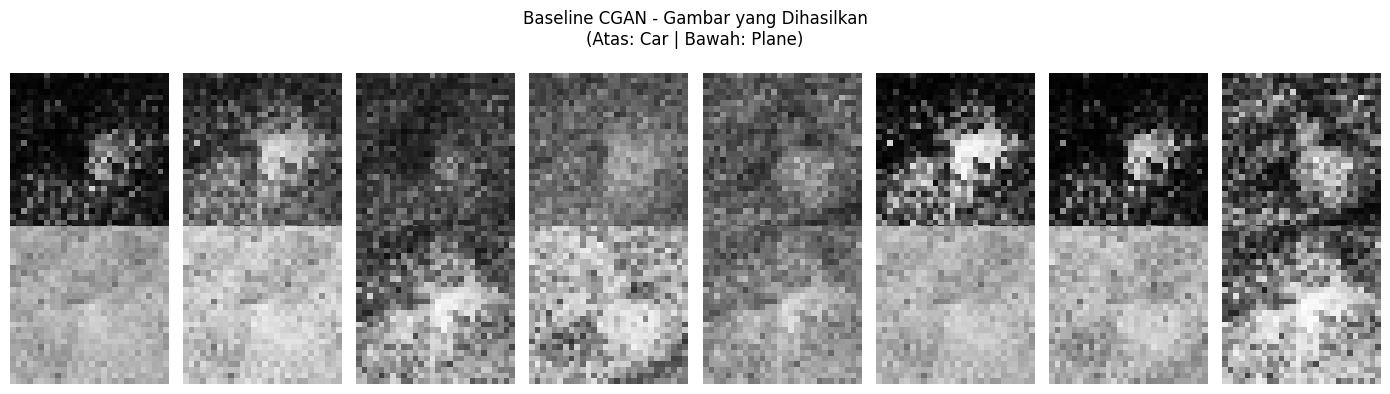

In [ ]:
# VISUALISASI GAMBAR YANG DIHASILKAN (BASELINE)
def generate_samples(generator, noise_dim, n_per_class=8, n_labels=2):
    """Generate gambar untuk setiap kelas."""
    generator.eval()
    fig, axes = plt.subplots(n_labels, n_per_class, figsize=(14, 4))
    class_names = ['Car', 'Plane']

    with torch.no_grad():
        for cls_idx in range(n_labels):
            noise  = torch.randn(n_per_class, noise_dim, device=device)
            labels = torch.full((n_per_class,), cls_idx, dtype=torch.long, device=device)
            imgs   = generator(noise, labels).cpu().numpy()  # (N, 784)
            imgs   = imgs.reshape(-1, 28, 28)                # (N, 28, 28)
            imgs   = (imgs + 1) / 2                          # [-1,1] -> [0,1]

            for i in range(n_per_class):
                axes[cls_idx, i].imshow(imgs[i], cmap='gray', vmin=0, vmax=1)
                axes[cls_idx, i].axis('off')
            axes[cls_idx, 0].set_ylabel(class_names[cls_idx], fontsize=11, rotation=90, labelpad=10)

    return fig

fig = generate_samples(gen_b, NOISE_DIM, n_per_class=8)
plt.suptitle('Baseline CGAN - Gambar yang Dihasilkan\n(Atas: Car | Bawah: Plane)', fontsize=12)
plt.tight_layout()
plt.savefig('baseline_cgan_generated.png', dpi=100)
plt.show()

Fungsi generate_samples menghasilkan 8 gambar untuk setiap kelas (Car dan Plane) menggunakan Generator yang sudah dilatih. Noise di sample dari distribusi Gaussian, label ditetapkan sesuai kelas, gambar di reshape ke 28x28 dan dinormalisasi ke [0,1].

gambar yang dihasilkan Baseline CGAN terlihat sangat noisy dan tidak memiliki struktur visual yang jelas, sulit membedakan mana yang seharusnya Car dan mana Plane. ini karena Generator gagal belajar akibat Discriminator yang dominan, output gambarnya pun tidak memiliki fitur yang jelas.

In [ ]:
# EVALUASI FID (BASELINE CGAN)
def get_real_test_images(test_loader):
    """Ambil semua gambar test sebagai numpy array (N, 28, 28)."""
    all_imgs = []
    for imgs, _ in test_loader:
        all_imgs.append(imgs.numpy().reshape(-1, 28, 28))
    return np.concatenate(all_imgs, axis=0)

def get_fake_images(generator, noise_dim, n_samples, n_labels):
    """Generate n_samples gambar palsu."""
    generator.eval()
    all_fake = []
    with torch.no_grad():
        for i in range(0, n_samples, 64):
            batch_n = min(64, n_samples - i)
            noise   = torch.randn(batch_n, noise_dim, device=device)
            labels  = torch.randint(0, n_labels, (batch_n,), device=device)
            imgs    = generator(noise, labels).cpu().numpy().reshape(-1, 28, 28)
            all_fake.append(imgs)
    return np.concatenate(all_fake, axis=0)

real_test_imgs = get_real_test_images(test_loader)
n_test = len(real_test_imgs)

print(f'Menghitung FID Baseline dengan {n_test} gambar...')
fake_imgs_b = get_fake_images(gen_b, NOISE_DIM, n_test, N_LABELS)
fid_baseline = calculate_fid(real_test_imgs, fake_imgs_b)
print(f'FID Baseline CGAN: {fid_baseline:.4f}')

Menghitung FID Baseline dengan 200 gambar...


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=Inception_V3_Weights.IMAGENET1K_V1`. You can also use `weights=Inception_V3_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 157MB/s] 
/tmp/ipykernel_1720/1139560763.py:56: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma_r @ sigma_f, disp=False)
/tmp/ipykernel_1720/1139560763.py:56: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean, _ = linalg.sqrtm(sigma_r @ sigma_f, disp=False)


FID Baseline CGAN: 125.0516


Gambar test asli diambil dari test_loader (200 gambar), dan 200 gambar palsu di-generate dari Baseline Generator. Kedua set gambar kemudian diproses oleh calculate_fid.

Outputnya adalah FID Baseline CGAN = 125.0516

nilai FID 125.0516 tergolong sangat tinggi, artinya distribusi gambar dari Baseline CGAN sangat berbeda dari distribusi gambar asli

## 3c. Modifikasi Arsitektur CGAN (Improved)

### Modifikasi

Setelah melihat hasil baseline, dilakukan modifikasi berikut:

1. **Deeper Generator dengan BatchNorm**: Generator yang lebih dalam (lebih banyak layer) dan BatchNorm agar gradient mengalir lebih stabil selama backprop.

2. **Spectral Normalization pada Discriminator**: Teknik standar stabilisasi GAN yang membatasi Lipschitz constant setiap layer Discriminator, mencegah Discriminator terlalu dominan (mode collapse).

3. **Label Smoothing**: Mengganti target real dari 1.0 → 0.9 (one-sided label smoothing). Terbukti mempersulit Discriminator terlalu percaya diri, sehingga gradient ke Generator lebih informatif.

4. **Dropout pada Discriminator**: Regularisasi agar Discriminator tidak overfit pada data training.

5. **Lebih Banyak Epoch + LR lebih kecil**: GAN butuh training lebih lama dan LR yang terkontrol untuk konvergensi yang stabil.

6. **Noise Dim lebih besar (128)**: Ruang laten yang lebih besar memberikan Generator lebih banyak "ruang" untuk menghasilkan variasi gambar.

In [ ]:
# ARSITEKTUR IMPROVED CGAN

class ImprovedGenerator(nn.Module):

    def __init__(self, noise_dim=128, n_labels=2, img_size=28, emb_dim=32):
        super().__init__()
        self.img_size  = img_size
        self.label_emb = nn.Embedding(n_labels, emb_dim)

        self.net = nn.Sequential(
            nn.Linear(noise_dim + emb_dim, 256),
            nn.BatchNorm1d(256),
            nn.LeakyReLU(0.2),

            nn.Linear(256, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, 1024),
            nn.BatchNorm1d(1024),
            nn.LeakyReLU(0.2),

            nn.Linear(1024, 512),
            nn.BatchNorm1d(512),
            nn.LeakyReLU(0.2),

            nn.Linear(512, img_size * img_size),
            nn.Tanh()
        )

    def forward(self, noise, labels):
        emb = self.label_emb(labels)
        x   = torch.cat([noise, emb], dim=1)
        return self.net(x)


class ImprovedDiscriminator(nn.Module):

    def __init__(self, n_labels=2, img_size=28, emb_dim=32, dropout=0.3):
        super().__init__()
        self.label_emb = nn.Embedding(n_labels, emb_dim)

        self.net = nn.Sequential(
            nn.utils.spectral_norm(nn.Linear(img_size * img_size + emb_dim, 1024)),
            nn.LeakyReLU(0.2),
            nn.Dropout(dropout),

            nn.utils.spectral_norm(nn.Linear(1024, 512)),
            nn.LeakyReLU(0.2),
            nn.Dropout(dropout),

            nn.utils.spectral_norm(nn.Linear(512, 256)),
            nn.LeakyReLU(0.2),
            nn.Dropout(dropout),

            nn.utils.spectral_norm(nn.Linear(256, 1)),
            nn.Sigmoid()
        )

    def forward(self, imgs, labels):
        emb = self.label_emb(labels)
        x   = torch.cat([imgs, emb], dim=1)
        return self.net(x)


NOISE_DIM_IMP = 128
gen_imp  = ImprovedGenerator(NOISE_DIM_IMP, N_LABELS, IMG_SIZE, emb_dim=32).to(device)
disc_imp = ImprovedDiscriminator(N_LABELS, IMG_SIZE, emb_dim=32, dropout=0.3).to(device)

print('=== GENERATOR (Improved) ===')
print(gen_imp)
print(f'\nParams Generator : {sum(p.numel() for p in gen_imp.parameters() if p.requires_grad):,}')
print('\n=== DISCRIMINATOR (Improved) ===')
print(disc_imp)
print(f'Params Discriminator: {sum(p.numel() for p in disc_imp.parameters() if p.requires_grad):,}')

=== GENERATOR (Improved) ===
ImprovedGenerator(
  (label_emb): Embedding(2, 32)
  (net): Sequential(
    (0): Linear(in_features=160, out_features=256, bias=True)
    (1): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): LeakyReLU(negative_slope=0.2)
    (3): Linear(in_features=256, out_features=512, bias=True)
    (4): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (5): LeakyReLU(negative_slope=0.2)
    (6): Linear(in_features=512, out_features=1024, bias=True)
    (7): BatchNorm1d(1024, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (8): LeakyReLU(negative_slope=0.2)
    (9): Linear(in_features=1024, out_features=512, bias=True)
    (10): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (11): LeakyReLU(negative_slope=0.2)
    (12): Linear(in_features=512, out_features=784, bias=True)
    (13): Tanh()
  )
)

Params Generator : 1,629,776

=== DISCRIMIN

ImprovedGenerator menggunakan noise dim yang lebih besar (128) dan embedding label berukuran 32 (bukan 2), sehingga input ke jaringan adalah 160-dim. Arsitektur jaringannya: 256 -> 512 -> 1024 -> 512 -> 784, dan yang paling penting, setiap layer Linear kini diikuti oleh BatchNorm1d sebelum LeakyReLU. BatchNorm menstabilkan distribusi aktivasi antar layer, mempercepat konvergensi, dan mengurangi sensitivitas terhadap inisialisasi bobot.

ImprovedDiscriminator menggunakan embedding label berukuran 32 (lebih efisien daripada 784 pada Baseline), sehingga input adalah 784 + 32 = 816-dim. Setiap layer Linear dibungkus dengan nn.utils.spectral_norm(), Spectral Normalization membatasi Lipschitz constant setiap layer dengan membagi bobotnya dengan nilai singular terbesar, mencegah Discriminator menjadi terlalu kuat dan menyebabkan gradient vanishing pada Generator. Selain itu, Dropout(0.3) ditambahkan setelah setiap LeakyReLU sebagai regularisasi agar Discriminator tidak overfit.

Outputnya adalah Generator Improved memiliki 1.629.776 parameter dan Discriminator yaitu 1.493.057 parameter.

In [ ]:
# TRAINING IMPROVED CGAN DENGAN TEKNIK STABILISASI

def train_cgan_improved(generator, discriminator, train_loader,
                        epochs=200, lr_g=1e-4, lr_d=1e-4,
                        noise_dim=128, n_labels=2,
                        label_smooth=0.9):

    criterion = nn.BCELoss()
    opt_G = optim.Adam(generator.parameters(), lr=lr_g, betas=(0.5, 0.999))
    opt_D = optim.Adam(discriminator.parameters(), lr=lr_d, betas=(0.5, 0.999))

    g_losses, d_losses = [], []

    for epoch in range(1, epochs+1):
        g_loss_ep, d_loss_ep = 0, 0
        generator.train()
        discriminator.train()

        for real_imgs, real_labels in train_loader:
            real_imgs   = real_imgs.to(device)
            real_labels = real_labels.to(device)
            N = real_imgs.size(0)

            # Label smoothing: real target = 0.9 bukan 1.0
            real_t = torch.full((N, 1), label_smooth, device=device)
            fake_t = torch.zeros(N, 1, device=device)

            # TRAIN DISCRIMINATOR
            opt_D.zero_grad()
            loss_real = criterion(discriminator(real_imgs, real_labels), real_t)

            noise      = torch.randn(N, noise_dim, device=device)
            fake_labels = torch.randint(0, n_labels, (N,), device=device)
            fake_imgs   = generator(noise, fake_labels).detach()
            loss_fake   = criterion(discriminator(fake_imgs, fake_labels), fake_t)

            loss_D = (loss_real + loss_fake) / 2
            loss_D.backward()
            opt_D.step()

            # TRAIN GENERATOR
            opt_G.zero_grad()
            noise     = torch.randn(N, noise_dim, device=device)
            gen_lbls  = torch.randint(0, n_labels, (N,), device=device)
            gen_imgs  = generator(noise, gen_lbls)
            # Generator ingin D menganggap gambarnya 'real' (target=1.0)
            loss_G    = criterion(discriminator(gen_imgs, gen_lbls),
                                  torch.ones(N, 1, device=device))
            loss_G.backward()
            opt_G.step()

            g_loss_ep += loss_G.item()
            d_loss_ep += loss_D.item()

        g_loss_ep /= len(train_loader)
        d_loss_ep /= len(train_loader)
        g_losses.append(g_loss_ep)
        d_losses.append(d_loss_ep)

        if epoch % 20 == 0 or epoch == 1:
            print(f'Epoch [{epoch:3d}/{epochs}] | G Loss: {g_loss_ep:.4f} | D Loss: {d_loss_ep:.4f}')

    return g_losses, d_losses


print('Mulai training Improved CGAN...')
g_losses_i, d_losses_i = train_cgan_improved(
    gen_imp, disc_imp, train_loader,
    epochs=200, lr_g=1e-4, lr_d=1e-4,
    noise_dim=NOISE_DIM_IMP, n_labels=N_LABELS,
    label_smooth=0.9
)

Mulai training Improved CGAN...
Epoch [  1/200] | G Loss: 0.7581 | D Loss: 0.6086
Epoch [ 20/200] | G Loss: 1.0562 | D Loss: 0.5865
Epoch [ 40/200] | G Loss: 1.0160 | D Loss: 0.6184
Epoch [ 60/200] | G Loss: 0.9758 | D Loss: 0.6300
Epoch [ 80/200] | G Loss: 0.9599 | D Loss: 0.6346
Epoch [100/200] | G Loss: 0.9667 | D Loss: 0.6470
Epoch [120/200] | G Loss: 0.9572 | D Loss: 0.6505
Epoch [140/200] | G Loss: 0.9547 | D Loss: 0.6389
Epoch [160/200] | G Loss: 0.9296 | D Loss: 0.6461
Epoch [180/200] | G Loss: 0.9262 | D Loss: 0.6457
Epoch [200/200] | G Loss: 0.9058 | D Loss: 0.6509


Fungsi train_cgan_improved menambahkan one-sided label smoothing, yaitu target untuk gambar asli diganti dari 1.0 menjadi 0.9 (label_smooth=0.9). Label smoothing mencegah Discriminator menjadi terlalu yakin pada prediksinya, sehingga gradient yang dikirim ke generator lebih informatif dan variatif. Learning rate diturunkan menjadi 1e-4 (dari 2e-4) dan jumlah epoch ditingkatkan menjadi 200.

Output training:
Epoch 1: Generator Loss 0.7581, Discriminator Loss 0.6086
Epoch 200: Generator Loss 0.9058, Discriminator Loss 0.6509

terdapat perbedaan mencolok dibanding Baseline. discriminator Loss yang konsisten berada di sekitar 0.58-0.65 mendekati nilai ideal ln(2) ≈ 0.693, menandakan Discriminator tidak lagi terlalu dominan. Generator Loss yang stabil di sekitar 0.90-1.05 menunjukkan adanya keseimbangan yang lebih baik antara generator dan discriminator. Kurva loss yang lebih stabil ini adalah tanda training GAN yang lebih stabil

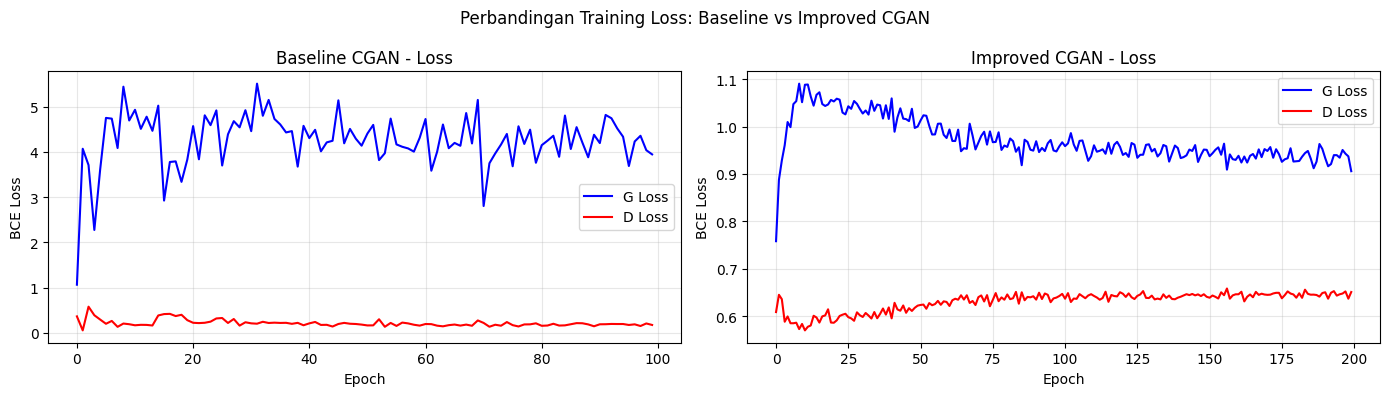

In [ ]:
# PLOT PERBANDINGAN LOSS
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(g_losses_b, label='G Loss', color='blue')
ax1.plot(d_losses_b, label='D Loss', color='red')
ax1.set_title('Baseline CGAN - Loss')
ax1.set_xlabel('Epoch'); ax1.set_ylabel('BCE Loss')
ax1.legend(); ax1.grid(True, alpha=0.3)

ax2.plot(g_losses_i, label='G Loss', color='blue')
ax2.plot(d_losses_i, label='D Loss', color='red')
ax2.set_title('Improved CGAN - Loss')
ax2.set_xlabel('Epoch'); ax2.set_ylabel('BCE Loss')
ax2.legend(); ax2.grid(True, alpha=0.3)

plt.suptitle('Perbandingan Training Loss: Baseline vs Improved CGAN', fontsize=12)
plt.tight_layout()
plt.savefig('cgan_loss_comparison.png', dpi=100)
plt.show()

Dua grafik ditampilkan berdampingan, yaitu loss baseline (100 epoch) dan loss improved (200 epoch).

Pada Baseline, terlihat Discriminator Loss langsung jatuh rendah di epoch awal sementara Generator Loss tinggi dan tidak stabil, tanda ketidakseimbangan. Pada Improved, kedua kurva loss bergerak lebih stabil di sepanjang 200 epoch. Ini menunjukkan bahwa teknik stabilisasi (Spectral Norm, BatchNorm, Label Smoothing) berhasil menciptakan keseimbangan yang lebih baik antara generator dan discriminator selama proses pelatihan.

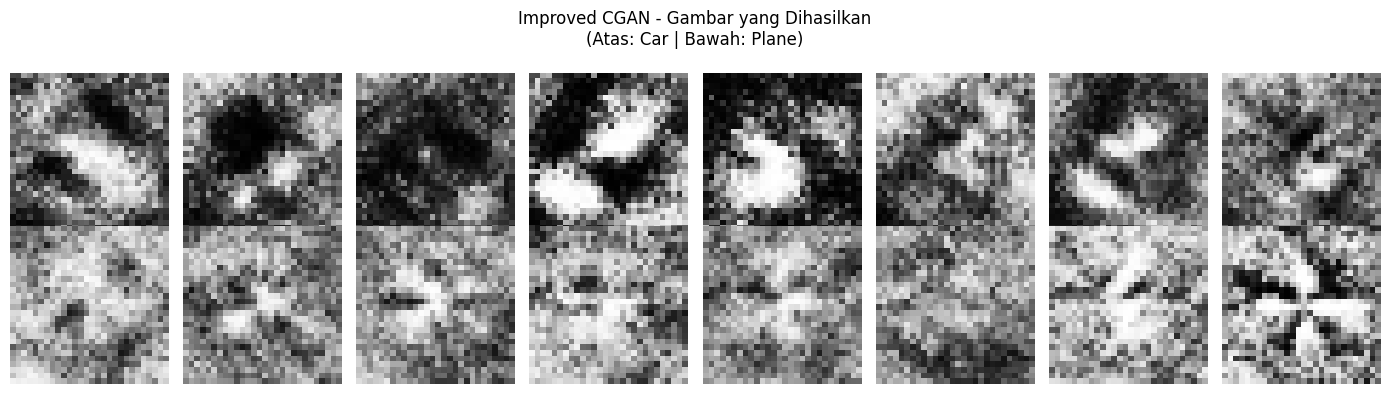

In [ ]:
# VISUALISASI GAMBAR HASIL (IMPROVED)
fig = generate_samples(gen_imp, NOISE_DIM_IMP, n_per_class=8)
plt.suptitle('Improved CGAN - Gambar yang Dihasilkan\n(Atas: Car | Bawah: Plane)', fontsize=12)
plt.tight_layout()
plt.savefig('improved_cgan_generated.png', dpi=100)
plt.show()

Gambar yang dihasilkan Improved CGAN ditampilkan dengan cara yang sama seperti Baseline.

Gambar dari Improved CGAN memiliki tekstur dan kontras yang lebih bervariasi dibanding Baseline. gambar Improved terlihat sedikit lebih tajam dan memiliki pola yang lebih terstruktur dibanding noise acak Baseline.

In [ ]:
# EVALUASI FID - IMPROVED CGAN
print(f'Menghitung FID Improved dengan {n_test} gambar...')
fake_imgs_i  = get_fake_images(gen_imp, NOISE_DIM_IMP, n_test, N_LABELS)
fid_improved = calculate_fid(real_test_imgs, fake_imgs_i)

print(f'\nPERBANDINGAN FID')
print(f'FID Baseline CGAN : {fid_baseline:.4f}')
print(f'FID Improved CGAN : {fid_improved:.4f}')
print(f'Selisih FID       : {fid_baseline - fid_improved:+.4f}')
if fid_improved < fid_baseline:
    print('Improved CGAN menghasilkan FID lebih rendah (lebih baik)!')
else:
    print('Pertimbangkan penambahan epoch untuk hasil yang lebih baik.')

Menghitung FID Improved dengan 200 gambar...


/tmp/ipykernel_1720/1139560763.py:56: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = linalg.sqrtm(sigma_r @ sigma_f, disp=False)
/tmp/ipykernel_1720/1139560763.py:56: LinAlgWarning: Matrix is singular. The result might be inaccurate or the array might not have a square root.
  covmean, _ = linalg.sqrtm(sigma_r @ sigma_f, disp=False)



PERBANDINGAN FID
FID Baseline CGAN : 125.0516
FID Improved CGAN : 90.2170
Selisih FID       : +34.8346
Improved CGAN menghasilkan FID lebih rendah (lebih baik)!


Improved CGAN berhasil menurunkan FID sebesar 34.83 poin (dari 125.05 menjadi 90.22). Ini menunjukkan bahwa kombinasi modifikasi arsitektur memberikan dampak. Namun nilai FID 90.22 masih tergolong tinggi, dan estimasi FID dengan 200 sampel memiliki keterbatasan akurasi karena matriks kovarians yang singular (terlihat dari LinAlgWarning di output).

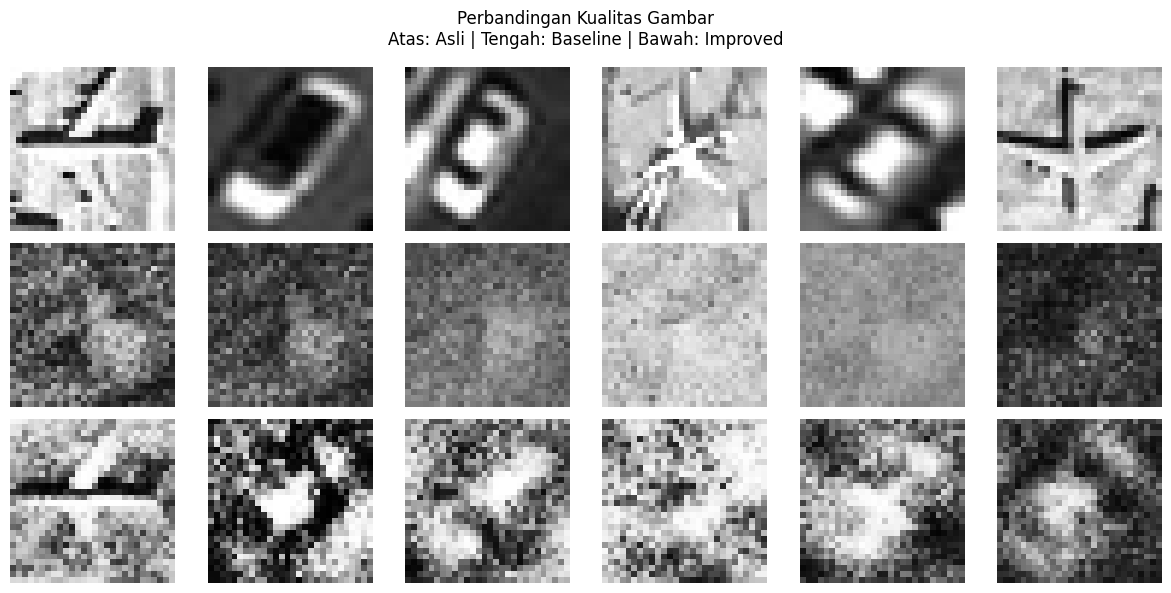

In [ ]:
# VISUALISASI SIDE BY SIDE : ASLI vs BASELINE vs IMPROVED
n = 6
fig, axes = plt.subplots(3, n, figsize=(12, 6))
fig.suptitle('Perbandingan Kualitas Gambar\nAtas: Asli | Tengah: Baseline | Bawah: Improved', fontsize=12)

# Real images (from test set), convert from [-1,1] to [0,1]
real_show = (real_test_imgs[:n] + 1) / 2
fake_b    = (fake_imgs_b[:n] + 1) / 2
fake_i    = (fake_imgs_i[:n] + 1) / 2

row_labels = ['Asli (Real)', f'Baseline\n(FID={fid_baseline:.1f})', f'Improved\n(FID={fid_improved:.1f})']
all_rows   = [real_show, fake_b, fake_i]

for row, (label, imgs) in enumerate(zip(row_labels, all_rows)):
    axes[row, 0].set_ylabel(label, fontsize=9, rotation=90, labelpad=5)
    for col in range(n):
        axes[row, col].imshow(imgs[col], cmap='gray', vmin=0, vmax=1)
        axes[row, col].axis('off')

plt.tight_layout()
plt.savefig('cgan_comparison.png', dpi=100, bbox_inches='tight')
plt.show()

Tiga baris gambar ditampilkan berdampingan, yaitu baris pertama adalah gambar asli dari test set, baris kedua gambar Baseline CGAN, dan baris ketiga gambar Improved CGAN. Gambar Baseline terlihat sangat noisy tanpa struktur yang dapat dikenali. Gambar Improved sedikit lebih baik dengan beberapa pola yang lebih terstruktur, tapi masih jauh dari kualitas gambar asli

## Kesimpulan

Implementasi CGAN pada dataset car dan plane menunjukkan ketidakseimbangan antara generator dan discriminator. Model Baseline mengalami kegagalan training yang cukup parah, ditandai dengan discriminator yang terlalu dominan (loss konsisten di bawah 0,3) sehingga generator tidak mampu belajar menghasilkan gambar yang dapat dikenali, menghasilkan FID sangat tinggi sebesar 125,05. Setelah diterapkan kombinasi teknik stabilisasi, yaitu BatchNorm pada Generator, Spectral Normalization dan Dropout pada Discriminator, label smoothing, learning rate yang lebih kecil, serta noise dimension dan jumlah epoch yang lebih besar, model Improved berhasil mencapai keseimbangan training yang jauh lebih baik (loss Discriminator stabil mendekati ln(2)=0,693) dan menurunkan FID menjadi 90,22, atau perbaikan sebesar 34,83 poin.

Walaupun demikian, kualitas gambar yang dihasilkan Improved CGAN secara visual masih jauh dari realistis dan belum mampu menampilkan struktur objek car maupun plane yang jelas, sehingga nilai FID yang dicapai masih tergolong tinggi. Hal ini menunjukkan bahwa arsitektur CGAN berbasis fully connected (tanpa konvolusi) memiliki keterbatasan kapasitas representasi untuk data citra, sehingga eksperimen lanjutan dengan arsitektur DCGAN (convolutional GAN), epoch yang jauh lebih banyak, atau teknik stabilisasi tambahan seperti Wasserstein loss masih diperlukan untuk memperoleh hasil generasi yang benar benar realistis